## Objetivo

Avaliar sua capacidade de compreender **quando, por que e como** utilizar RAG em uma aplicação real.

Você deverá escolher **2 cenários diferentes** nos quais uma arquitetura RAG poderia ser utilizada e projetar, para cada um, uma solução completa, desde a entrada dos documentos até a geração da resposta pelo modelo de linguagem.

Esta é uma atividade de **projeto**, não de implementação. Não é preciso escrever código. O que se espera é arquitetura, decisão e justificativa.

## Escolha dos cenários

Os dois cenários devem ser **substancialmente diferentes** entre si - não escolha "FAQ de uma loja de roupas" e "FAQ de uma loja de eletrônicos". Bons contrastes envolvem diferenças em tipo de documento, volume, frequência de atualização, criticidade do erro ou perfil do usuário.

Escolha cenários sobre os quais você tenha alguma familiaridade real. Um cenário que você conhece de perto produz decisões muito melhores que um cenário genérico.

# Parte 1 - Identificação dos problemas

Para **cada um dos 2 cenários**, responda:

## 1.1 Descrição do problema

- Qual é o problema que você deseja resolver?
- Quem utilizaria a aplicação? Descreva o usuário concretamente: cargo, contexto de uso, nível técnico.
- Que tipo de informação o usuário gostaria de consultar?
- De onde vêm essas informações?
- Por que utilizar um LLM sozinho não seria suficiente?
- Como o usuário vai utilizar o sistema? (API, aplicativo, interface web?)

Escreva também três perguntas reais que um usuário faria ao sistema.

Perguntas concretas, do jeito que a pessoa falaria - não títulos de tópico.

# Respostas do 1.1

# Qual é o problema que você deseja resolver?
## Problemas:
## - Departamento de Suporte: Permitir a consulta a base de dados de atendimento de tickets resolvidos para visualizar a solução adotada em problemas semelhantes em tickets novos.

## - Departamento de RH: Permitir a consulta a base de dados de funcionarios para identificar dados cadastrais, periodos de férias e promoções.

# Quem utilizaria a aplicação? Descreva o usuário concretamente: cargo, contexto de uso, nível técnico.
# Que tipo de informação o usuário gostaria de consultar?

## - Departamento de Suporte ao usuário e departamento de RH.
## - Colaboradores que atuam no suporte aos usuários podem fazer uso do RAG para acessar a base de tickets resolvidos.
## - Colaboradores do RH podem consultar dados dos demais colaboradores e administrar as informações relacionadas ao colaborador.


# Que tipo de informação o usuário gostaria de consultar?

## - informações sobre tickets resolvidos
## - informações sobre documentação, periodo de trabalho, férias, salários, etc...

# De onde vêm essas informações?
## - base de dados histórico de atendimentos fechados.
## - base de dados de colaboradores ativos.

# Por que utilizar um LLM sozinho não seria suficiente?
## - Uma LLM foi treinada com base de dados tipo wikipedia, livros, artigos, etc...
## - Dados confidencias de empresas não fazem do treinamento e por consequencia o LLM não tem como responder a respeito desse assunto.
## - A estratégia do RAG permite acrescentar conhecimento para o LLM.


# Como o usuário vai utilizar o sistema? (API, aplicativo, interface web?)

## - Depende da situação, se deseja uma resposta única e completa.
## - Uma consulta a tickets resolvidos, seria feita pelo pessoal do suporte através de uma interface web, onde visualizaria a solução e poderia repassar para o usuário. Ou ir pessoalmente e aplicar a solução encontrada.
## - no RH a consulta a dados de colaboradores é confidencial, pode ser feita via interface web, com acesso apenas via login e senha.

# Perguntas que o usuário poderia fazer:
## Suporte
## - Quais tickets resolvidos a respeito de impressoras ?
## - Quantos tickets resolvidos foram a respeito da impressora modelo Nasa?
## - Qual o ticket mais antigo de impressoras ?
## RH
## - Quando o colaborador João terá direito a férias remuneradas ?
## - Qual o cargo do colaborador João ?
## - Quais colaboradores tem 5 anos de trabalho na empresa ?


## 1.2 Por que RAG?

- Por que RAG é adequado para esse problema?
- Que tipo de conhecimento precisa ser fornecido ao modelo?
- Esse conhecimento muda com que frequência? (diariamente, mensalmente, quase nunca?)
- Existe necessidade de utilizar documentos privados ou específicos da organização?
- Que problemas poderiam ocorrer se o LLM respondesse apenas com seu conhecimento pré-treinado? **Dê um exemplo concreto de resposta errada** que ele daria no seu cenário.

# Resposta 1.2

# Por que RAG é adequado para esse problema?
## - A base de dados são documentos que podem ser indexados, por data, por departamento, por tipo, assim a criamos um base preparada para filtrar e assim recuperar trechos relevantes em nossas pesquisas.
## - Essa base pode ser facilmente atualizada e assim garantir a consistências das respostas obtidas.

# Que tipo de conhecimento precisa ser fornecido ao modelo?
## - Documentos relevantes que sejam necessários para gerar a reposta correta.
## - Podem ser relatórios administrativos ou histórico de atendimentos.

# Esse conhecimento muda com que frequência? (diariamente, mensalmente, quase nunca?)
## - Dados administrativos podem mudar diariamente, semanalmente ou anualmente.
## - Históricos de atendimentos, podem ser atualizados semanalmente.

# Existe necessidade de utilizar documentos privados ou específicos da organização?
## - No departamento de RH, são dados confidenciais, o acesso é controlado.
## - No departamento de suporte envolve apenas dados da própria empresa, departamentos e equipamentos.

# Que problemas poderiam ocorrer se o LLM respondesse apenas com seu conhecimento pré-treinado? Dê um exemplo concreto de resposta errada que ele daria no seu cenário.
## - Nenhuma LLM poderia responder a respeito de questões de RH de uma empresa, pois foi treinado com bases gerais, que não fazem referência a qualquer empresa.
## - Se perguntar para a LLM qual a faixa salarial de determinado cargo na empresa A, podem nem existir esse cargo na empresa A. Mesmo que exista, esse informação não é divulgada, a LLM pode ter pesquisado e encontrado uma média.


## 1.3 Limitações - quando RAG *não* é a resposta

Em quais situações RAG **não** seria a melhor solução para esse problema?

Considere e comente ao menos três alternativas:

- busca tradicional por palavra-chave;
- banco de dados estruturado e consultas SQL;
- regras determinísticas;
- utilização direta de uma API;
- combinação de alguma dessas técnicas com RAG.

# Respostas 1.3

# Em quais situações RAG não seria a melhor solução para esse problema?

# Considere e comente ao menos três alternativas:

# - busca tradicional por palavra-chave;
## - O significado de uma palavra-chave tem relação com o contexto.
## - O mesmo termo pode ter significados totalmente diferentes.
## - Não compreende a intenção da pergunta, apenas busca por termos exatos, o que pode resultar em respostas incompletas ou irrelevantes se o termo não estiver explicitamente presente.

# - banco de dados estruturado e consultas SQL
## - bancos de dados relacionais, dependem de relacionamentos, a linguagem SQL faz isso perfeitamente.
## - podem existir diversas tabelas, dimensões e tabelas fato, através do SQL, através de filtros, recuperar, gerar calculos e obter uma resposta.
## - Para consultas que exigem precisão, agregações (somas, contagens, médias) e filtros complexos sobre dados estruturados, um banco de dados relacional com SQL é muito mais eficiente e preciso do que o RAG.

# - regras determinísticas;
## - Para problemas que possuem respostas fixas, claras e que não variam com o contexto ou que não exigem interpretação de linguagem natural, regras determinísticas (ex: if-then-else statements, tabelas de decisão) são mais simples, rápidas e menos propensas a erros e alucinações que um LLM com RAG.

# - utilização direta de uma API;
## - Se a informação desejada já está disponível através de uma API bem definida que retorna dados estruturados (ex: status de um pedido, cotação de uma ação, informações de um usuário por ID), a chamada direta a essa API é mais eficiente e confiável do que tentar extrair essa informação através de um RAG que precisaria interpretar a pergunta e, talvez, interagir com a API de forma indireta.

# - combinação de alguma dessas técnicas com RAG.
## - Em muitos casos complexos, a melhor solução é uma arquitetura híbrida. Por exemplo, usar RAG para entender a intenção da pergunta e extrair entidades, mas delegar a execução de consultas agregadas ou a busca de dados estruturados para um banco de dados SQL ou uma API específica. O RAG então combinaria os resultados para formar uma resposta completa e coerente.

## **Responda também:**

- Existe alguma pergunta, dentro do seu próprio cenário, que RAG responderia **mal** e um banco de dados relacional responderia bem? Qual, e por quê?
## - Sim, para o cenário de RH, a pergunta "Quantos colaboradores foram promovidos em 2023?" seria respondida mal pelo RAG. O RAG recuperaria documentos que mencionam promoções em 2023, mas teria dificuldade em **contar** de forma precisa o número exato de ocorrências ou de filtrar exclusivamente promoções, especialmente se a informação estiver espalhada ou implícita em textos. Um banco de dados relacional, por outro lado, com uma tabela de histórico de promoções, responderia essa pergunta de forma exata e eficiente com uma consulta SQL como `SELECT COUNT(*) FROM promocoes WHERE ano = 2023;`.

- O que aconteceria se a pergunta do usuário exigisse **contar**, **somar** ou **ordenar** informação espalhada por muitos documentos?
## - O RAG enfrentaria grandes dificuldades. Embora um LLM possa ter alguma capacidade de "contar" ou "somar" informações em um ou poucos parágrafos recuperados, ele não é projetado para realizar operações matemáticas precisas ou ordenação de dados em larga escala de forma confiável em múltiplos documentos. Ele poderia alucinar números, somar incorretamente ou apresentar uma ordenação subjetiva e inconsistente, pois seu foco é a coerência textual e a recuperação de informações relevantes, não a análise quantitativa ou estruturada. Para tais operações, um sistema que combine RAG com ferramentas de análise de dados estruturados (como SQL, Pandas, etc.) seria essencial.

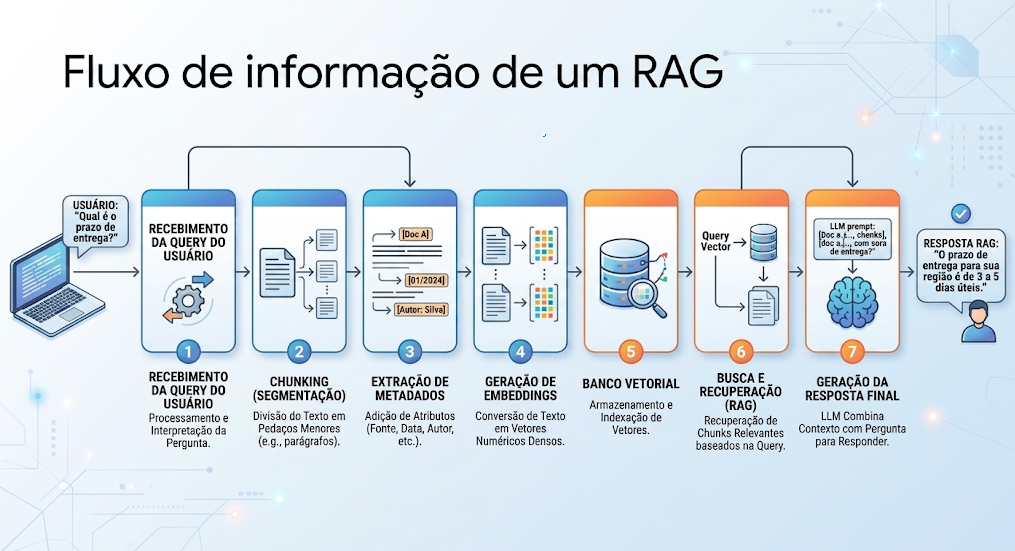